<h1 style="color: orange; font-size: 40px; font-weight: bold;">
LAB 9
</h1>

<h2 style="color: green; font-size: 35px; font-weight: bold;">
Genetic algorithm
</h2>

<p style="color: blue; font-size: 25px; font-weight: bold;">
Travelling salesman problem
</p>

This problem consists in a salesman and a set of  cities with positions 
$\mathbf{x}_i$. The salesman has to visit each one of the cities starting from a certain one (e.g. the hometown) and returning to the same city. The challenge of the problem is that the traveling salesman wants to minimize the total length of the trip. The best path is the one that minimizes the following loss function:
$$
L^{(1)}(\mathbf{x}_1,...,\mathbf{x}_N)=\sum_{i=1}^N|\mathbf{x}_i-\mathbf{x}_{i+1}|
$$
TSP fits in the class of NP-hard optimization problems: given a path it is straightforward to compute L(x) to judge its efficiency, on the other hand, finding the best path among all the possible ones becomes rapidly difficult as the number of cities grows. Its complexity scales exponentially with the number of cities involved. This challenge lead to the developement of metaheuristic algorithms such as the genetic algorithm.

Inspired by evolutional biology, the algorithm idea is to organize the cities as genes in a chromosome, that will contain a possible path. All the chromosomes are then put in a population. The TSP constraints are that the salseman must never visit the same city twice, and at the end of the journey he must turn back to the first city. To accont for this, the first gene (the starting city) in each chromosome has been fixed. The passage from the last city to the first one has been accounted only in the loss calculation. `bool check_function();` method checks if this constraints are satisfied every time a chromosome is modified or created during the optimization.

The code is organized in two main classes: the individual class and the population one. In the individual class we store the genes and the value of the cost function.
`class population` implement methods that allow the population to evolve, like mutations and crossover operators.

The intial population is generated in the population class constructor by creating a template chromosome containing all the cities sorted in ascending order, and then each new chromosome in the population is made by shuffling i genes every N-i times in the template (always without choosing the first gene). This method automatically grants that there will not be chromosomes with duplicated genes (so that every city is visited only once).

<p style="color: red; font-size: 15px; font-weight: bold;">
Mutation operators
</p>

We employs the following kind of mutation:
- pair permutation of cities (except for the first city), e.g. $[1,2,3,4,5]\to[1,2,4,3,5]$.
- shift of $n$ positions for $m$ contiguous cities (except for the first city and $m<N-1$)
- permutation among $m$ contiguous cities (except for the first city) with other (different!) $m$ contiguous cities ($m<N/"$)
- inversion of the order in which they appear in the path of $m$ cities (except for the first city and $m<N$)

<p style="color: red; font-size: 15px; font-weight: bold;">
Crossover operators
</p>

The reproduction of population is modeled by the crossover operator: given a selected mother and father, e.g.
$$
[1,2,3,4,5][1,5,4,3,2]
$$
1. cut their paths at the same position:
$$
[1,2,3|4,5][1,5,4|3,2]
$$
2. conserve the first part of the paths:
$$
[1,2,3|X,Y][1,5,4|X,Y]
$$
3. complete the paths with the missing cities adding them in the order in which they appear in the consort:
$$
[1,2,3|5,4][1,5,4|2,3]
$$

The used values of the hyperparameters linked to the mutation and crossover operation are set to:
$$
P_{pair} = 0.05 \\
P_{shift} = 0.1 \\
P_{perm} = 0.07 \\
P_{inv} = 0.1 \\
P_{cross} = 0.6
$$

<p style="color: red; font-size: 15px; font-weight: bold;">
Selector operator and elitism
</p>

To create a new population which is better than the previous in an efficient way, fathers and mothers can't be chosen completely blindly. Selection is made with an **unfair roulette selection operator** the individuals in the population are sorted by fitness ( by increasing order of loss) and then one choose the best individuals with higher probability. Here the Selection function that made this task:
```cpp
Individual population :: selector(){ // Only if the population have been already sorted
    int j = int(N_ind * pow(_rnd.Rannyu(), 2.0));
    return Pop[j];
}
```
where we set the exponent p to 2.
On the other hand, **elitism** gives the possibility tho chose to copy N among the best indiviuals into the next population. This, if N is tuned properly, can lead to a faster convergence. In this case N=1 was sufficient: increasing furtherly N would reduce the variability and the algorithm becomes more susceptible to get stuck in local minimums. To avoid limitating the stochasticity of the algorithm, we choose to insert the elist with 60% probability.

<p style="color: red; font-size: 15px; font-weight: bold;">
Evolution
</p>

The evolution core is implemented in the function `void population :: evolution(int ev_step);` This function performs mutations and crossover and then replaces the old population with a new one.

The evolution is carried out up to a maximum number of generations, N_gen_max, which must be properly tuned to avoid performing unnecessary iterations after convergence has already been reached.

In the following plots, we consider 34 cities randomly distributed either on a circumference or inside a square, and we set the maximum number of generations to 1000. This choice illustrates that convergence is achieved much earlier, while the value of the loss function quickly reaches a plateau.

In [42]:
import matplotlib.pyplot as plt
import numpy as np

def plot_function(data, data_loss, type):
    gen = data_loss[:, 0]
    best_L = data_loss[:, 1]
    averaged_L = data_loss[:, 2]

    cities = data[:, 0].astype(int)
    x = data[:, 1]
    y = data[:, 2]

    # chiusura del percorso
    x_plot = np.append(x, x[0])
    y_plot = np.append(y, y[0])


    fig, ax = plt.subplots(1, 2, figsize=(20, 10))
    ax[0].plot(x_plot, y_plot, '-o', linewidth=1.5)
    ax[0].plot(x[0], y[0], marker='s', color='green', markersize=10, label='Start/End')
    if (type=="circle"):
        theta = np.linspace(0, 2 * np.pi, 300)
        r = 1.0 
        xc = r * np.cos(theta)
        yc= r* np.sin(theta)
        ax[0].plot(xc, yc, 'g--', label='Circumference')
    for i, city_id in enumerate(cities):
        ax[0].text(x[i], y[i], f'{city_id}', fontsize=10, verticalalignment='bottom')
    ax[0].grid(True, linestyle=':', alpha=0.6)
    ax[0].set_title("Genetic algorithm on " + type)
    ax[0].set_xlabel("X", fontsize=12)
    ax[0].set_ylabel("Y", fontsize=12)
    ax[0].legend()
    ax[0].axis('equal')

    ax[1].plot(gen, best_L, label=r'Best $L^1$')
    ax[1].plot(gen, averaged_L, label=r'Average $L^1$ (best half of population)', color='orange', linestyle='--')
    ax[1].set_xlabel("Generations")
    ax[1].set_ylabel(r"$L^1$")
    ax[1].set_title("Fitness during optimization on " + type)
    ax[1].grid(True)
    ax[1].legend()


    plt.tight_layout()

    plt.show()


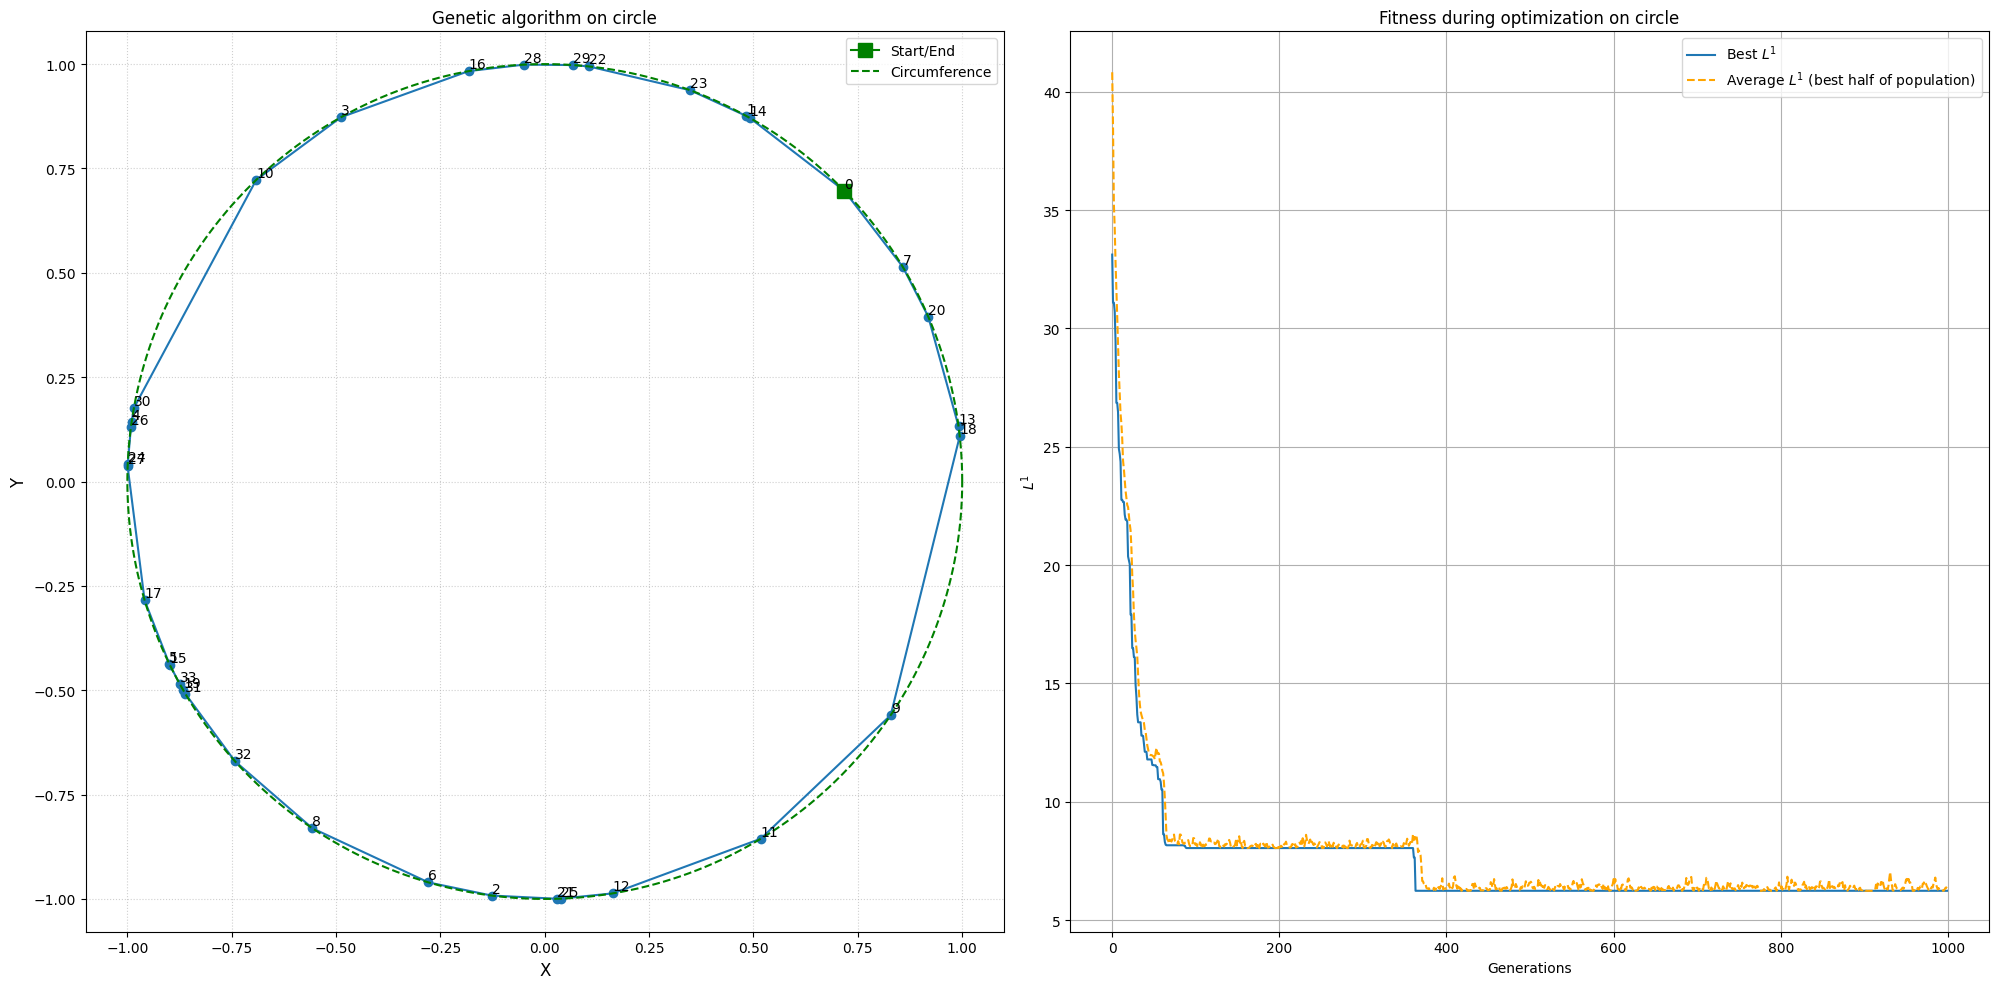

best final loss for circ = 6.24306


In [43]:
%matplotlib inline

data = np.loadtxt("OUTPUT/Path_circo.xy", skiprows=1)
data_loss = np.loadtxt("OUTPUT/Loss_values_circo.dat", skiprows=1)

plot_function(data, data_loss, "circle")
print(f"best final loss for circ = {data_loss[-1, 1]}")

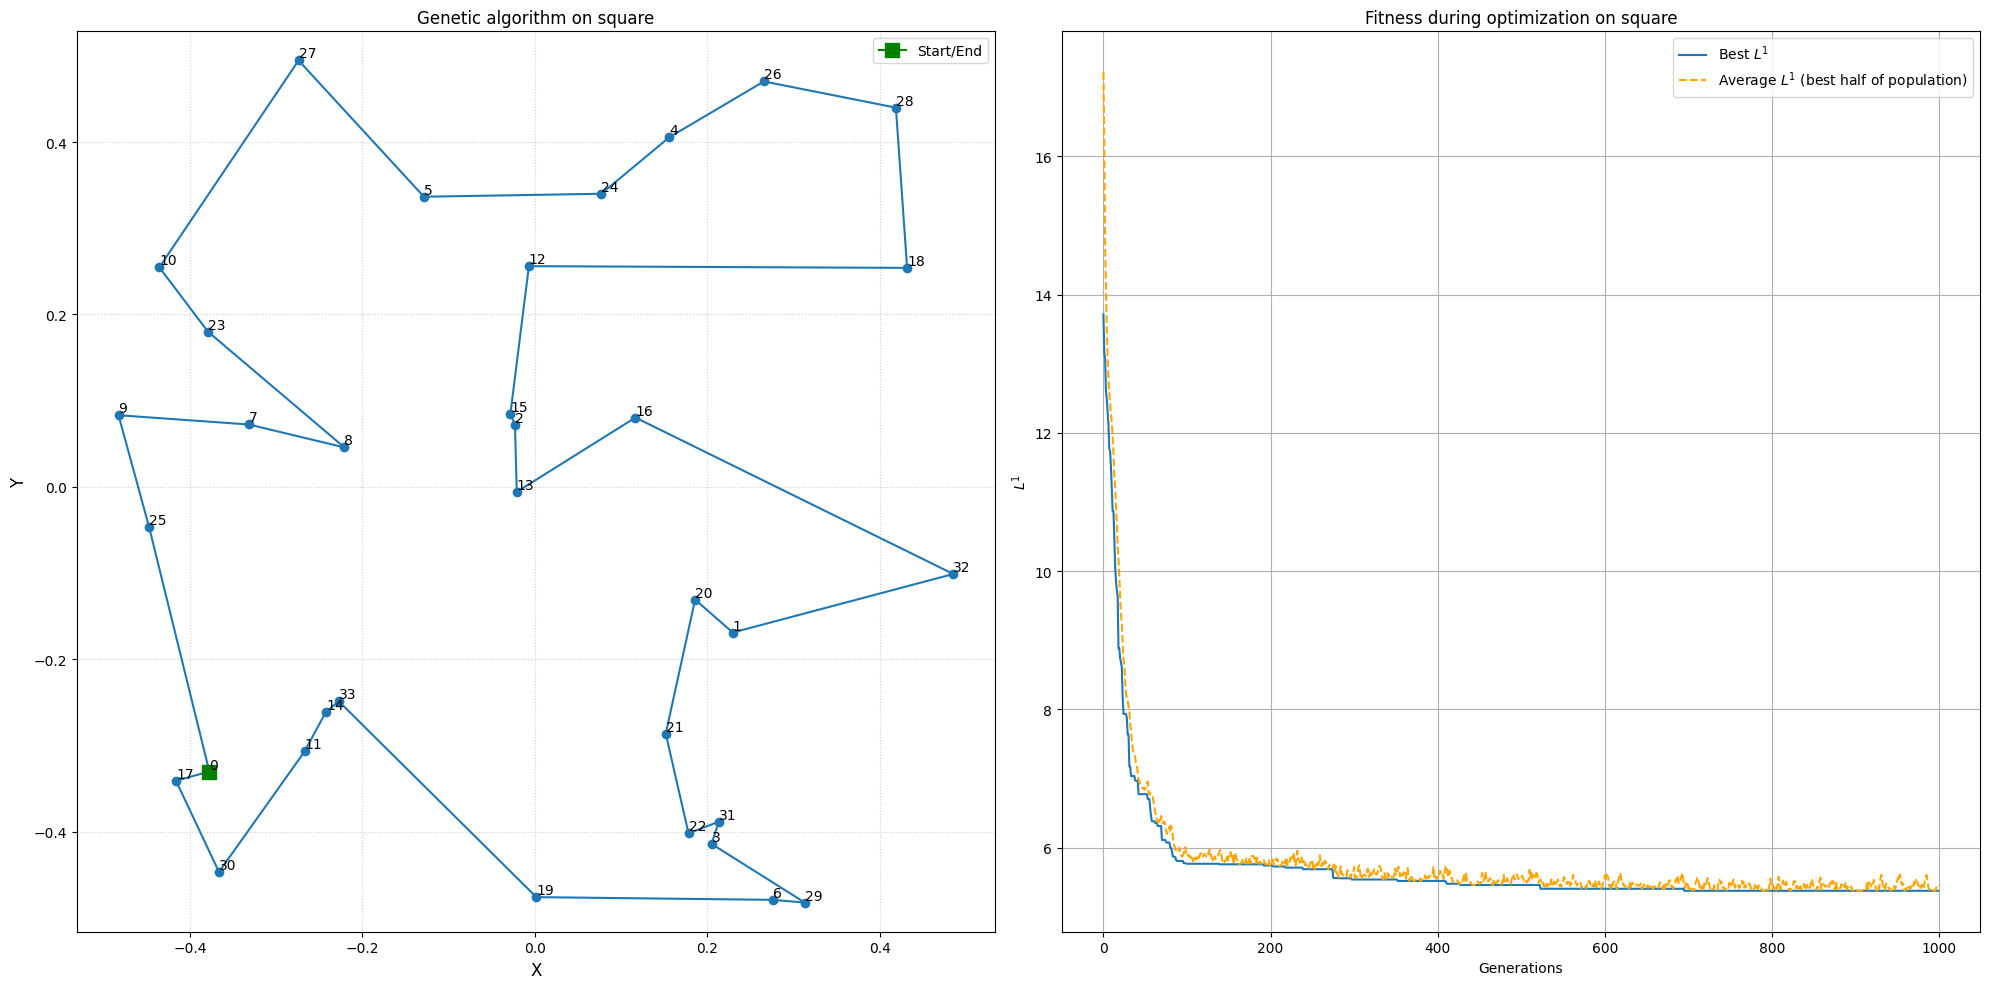

best final loss on square = 5.37821


In [44]:
%matplotlib inline

data = np.loadtxt("OUTPUT/Path_square.xy", skiprows=1)
data_loss = np.loadtxt("OUTPUT/Loss_values_square.dat", skiprows=1)

plot_function(data, data_loss, "square")
print(f"best final loss on square = {data_loss[-1, 1]}")